In [69]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

Library numpy untuk membantu manipulasi array dan matriks. Library matplotlib.pyplot untuk menampilkan hasil citra ke dalam bentuk visual. library cv2. untuk membaca file gambar, mengubah format warna, melakukan transformasi citra, serta berbagai operasi lain seperti filtering, deteksi objek, dan manipulasi piksel.

(720, 720, 3)


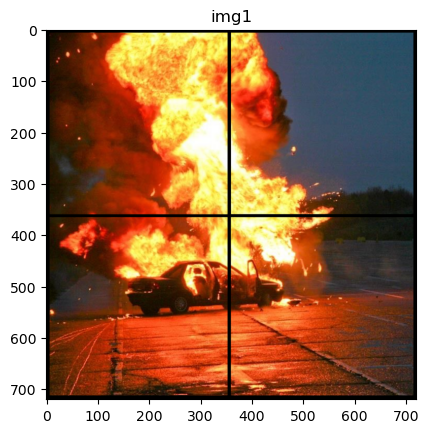

In [2]:
img1 = plt.imread("Assets/Meledak.PNG")
plt.imshow(img1)
plt.title("img1")
print(img1.shape)

plt.imread("Assets/Meledak.PNG"), program mengambil file gambar bernama Meledak.PNG yang berada di dalam folder Assets, kemudian menyimpannya ke dalam variabel img1. fungsi plt.imshow(img1) digunakan untuk menampilkan gambar.plt.title("img1") memberikan judul tampilan gambar.print(img1.shape), program menampilkan dimensi atau ukuran array citra..

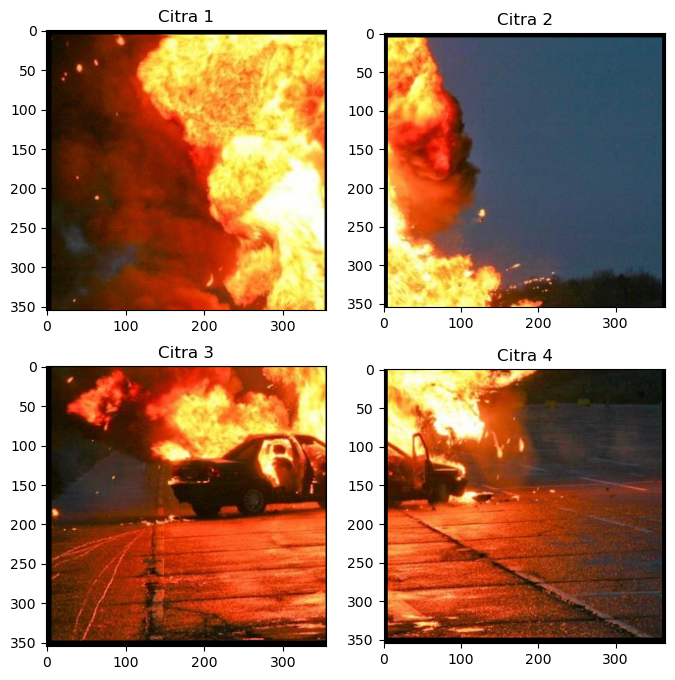

In [201]:
def fungsi_empat_S(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

bagian_atas = fungsi_empat_S(img1, 0, 355, mode='H')
bagian_bawah = fungsi_empat_S(img1, 365, 730, mode='H')

citra_1 = fungsi_empat_S(bagian_atas, 0, 355, mode='V')
citra_2 = fungsi_empat_S(bagian_atas, 355, 730, mode='V')

citra_3 = fungsi_empat_S(bagian_bawah, 0, 355, mode='V')
citra_4 = fungsi_empat_S(bagian_bawah, 355, 730, mode='V') 

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(citra_1)

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(citra_2)

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(citra_3)

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(citra_4)

plt.show()

Proses dimulai dengan pembuatan fungsi fungsi_empat_S() yang bertugas melakukan cropping citra.parameter mode bernilai 'H', maka fungsi akan memotong gambar secara horizontal dengan mengambil rentang baris tertentu dan mempertahankan seluruh kolom.img1 dibagi menjadi dua bagian utama, yaitu bagian_atas dan bagian_bawah. Variabel bagian_atas mengambil area gambar dari baris 0 hingga 355, sedangkan bagian_bawah mengambil area dari baris 365 hingga 730, masing-masing bagian kembali dipotong secara vertikal sehingga menghasilkan empat citra berbeda. citra_1 dan citra_2 berasal dari bagian atas gambar, sedangkan citra_3 dan citra_4 berasal dari bagian bawah gambar.

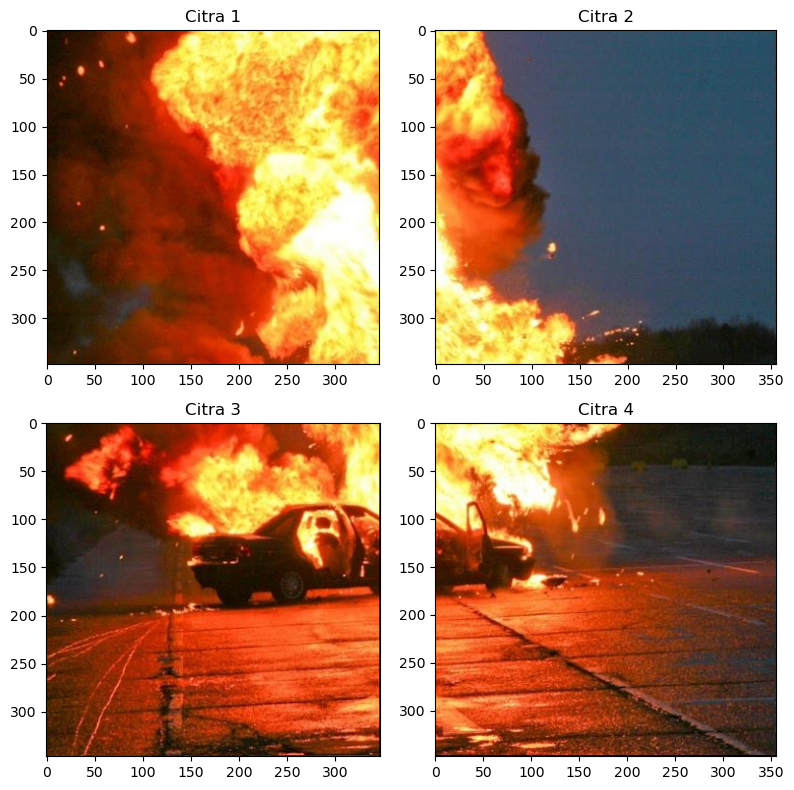

In [206]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h * 2, w * 2)).astype(int)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

citra_1_int = (citra_1 * 255).astype(int)
citra_2_int = (citra_2 * 255).astype(int)
citra_3_int = (citra_3 * 255).astype(int)
citra_4_int = (citra_4 * 255).astype(int)

def crop_hitam(image):
    if image.dtype == float:
        image = (image * 255).astype(int)

    if len(image.shape) == 3:
        h, w, c = image.shape
    else:
        h, w = image.shape
        c = 1

    # Cari y1
    y1 = -1
    for y in range(h):
        for x in range(w):
            if c == 1:
                nilai = image[y][x]
            else:
                nilai = image[y][x][0] + image[y][x][1] + image[y][x][2]
            if nilai > 0:
                y1 = y
                break
        if y1 != -1:
            break

    # Cari y2
    y2 = -1
    for y in range(h - 1, -1, -1):
        for x in range(w):
            if c == 1:
                nilai = image[y][x]
            else:
                nilai = image[y][x][0] + image[y][x][1] + image[y][x][2]
            if nilai > 0:
                y2 = y
                break
        if y2 != -1:
            break

    # Cari x1
    x1 = -1
    for x in range(w):
        for y in range(h):
            if c == 1:
                nilai = image[y][x]
            else:
                nilai = image[y][x][0] + image[y][x][1] + image[y][x][2]
            if nilai > 0:
                x1 = x
                break
        if x1 != -1:
            break

    # Cari x2
    x2 = -1
    for x in range(w - 1, -1, -1):
        for y in range(h):
            if c == 1:
                nilai = image[y][x]
            else:
                nilai = image[y][x][0] + image[y][x][1] + image[y][x][2]
            if nilai > 0:
                x2 = x
                break
        if x2 != -1:
            break

    if y1 == -1 or x1 == -1:
        return image

    return image[y1:y2+1, x1:x2+1]

zoom1 = crop_hitam(citra_1_int)
zoom2 = crop_hitam(citra_2_int)
zoom3 = crop_hitam(citra_3_int)
zoom4 = crop_hitam(citra_4_int)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(zoom1)

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(zoom2)

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(zoom3)

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(zoom4)

plt.tight_layout()
plt.show()

Fungsi fungsi_tiga() dibuat untuk melakukan proses dilasi atau pembesaran citra secara manual dengan menggandakan ukuran gambar menjadi dua kali lebih besar dari ukuran aslinya.setiap citra hasil pemotongan (citra_1, citra_2, citra_3, dan citra_4) diubah terlebih dahulu ke bentuk integer dengan mengalikan nilai piksel dengan 255.fungsi crop_hitam() digunakan untuk menghapus area hitam kosong di sekitar gambar.Hasil dari proses cropping disimpan dalam variabel zoom1, zoom2, zoom3, dan zoom4.

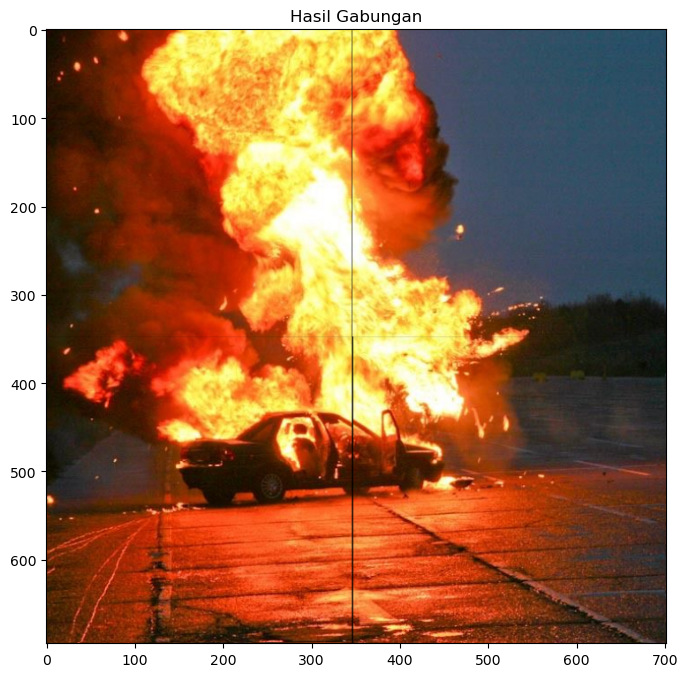

In [ ]:
def merge_image(citra1, citra2, orientation='H'):

    if orientation == 'H':
        tinggi_min = min(citra1.shape[0], citra2.shape[0])

        c1 = citra1[0:tinggi_min, :]
        c2 = citra2[0:tinggi_min, :]

        lebar_total = c1.shape[1] + c2.shape[1]

        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi_min, lebar_total), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_min, lebar_total, citra1.shape[2]), dtype=citra1.dtype)

        gabungan[0:tinggi_min, 0:c1.shape[1]]                       = c1
        gabungan[0:tinggi_min, c1.shape[1]:c1.shape[1]+c2.shape[1]] = c2

    else:
        lebar_min = min(citra1.shape[1], citra2.shape[1])

        c1 = citra1[:, 0:lebar_min]
        c2 = citra2[:, 0:lebar_min]

        tinggi_total = c1.shape[0] + c2.shape[0]

        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi_total, lebar_min), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_total, lebar_min, citra1.shape[2]), dtype=citra1.dtype)

        gabungan[0:c1.shape[0], 0:lebar_min]                        = c1
        gabungan[c1.shape[0]:c1.shape[0]+c2.shape[0], 0:lebar_min]  = c2

    return gabungan

merge_1     = merge_image(zoom1, zoom2, 'H')
merge_2     = merge_image(zoom3, zoom4, 'H')
merge_final = merge_image(merge_1, merge_2, 'V')

plt.figure(figsize=(8, 8))
plt.imshow(merge_final)
plt.title("Hasil Gabungan")

plt.show()

Fungsi merge_image() dibuat untuk menangani proses penggabungan citra dengan parameter citra1 dan citra2 sebagai gambar yang akan digabungkan, sedangkan parameter orientation menentukan arah penggabungan. terlebih dahulu mencari tinggi terkecil dari kedua citra menggunakan fungsi min(). etelah itu, masing-masing citra dipotong mengikuti tinggi minimum tersebut dan disimpan dalam variabel c1 dan c2.Lebar total hasil gabungan kemudian dihitung dari penjumlahan lebar kedua gambar lalu membuat array kosong bernama gabungan menggunakan np.zeros() sebagai wadah untuk hasil penggabungan. Setelah fungsi selesai dibuat melakukan penggabungan beberapa citra hasil proses sebelumnya. zoom1 dan zoom2 digabung secara horizontal dan disimpan dalam merge_1, sedangkan zoom3 dan zoom4 digabung secara horizontal menjadi merge_2. Selanjutnya, kedua hasil tersebut kembali digabung secara vertikal untuk menghasilkan satu citra utuh yang disimpan dalam merge_final.

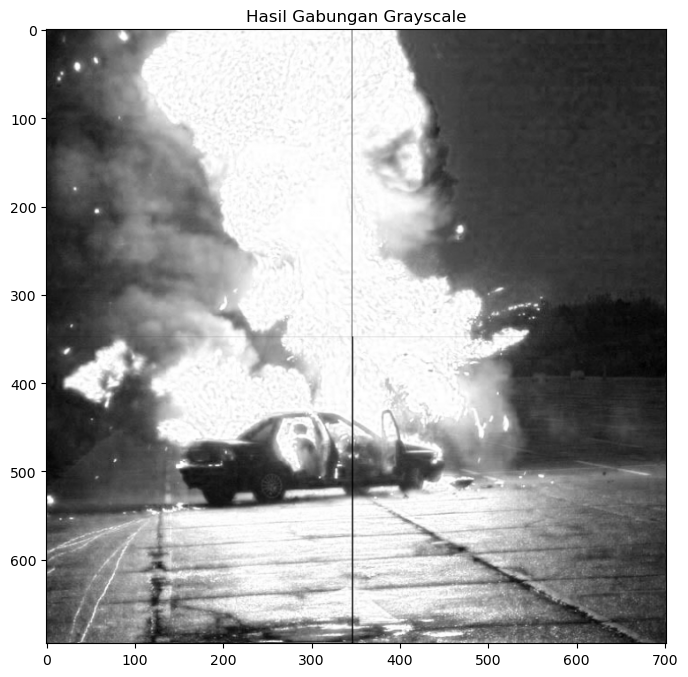

In [73]:
plt.figure(figsize=(8, 8))
plt.imshow(merge_final[:,:,0], cmap = "gray" )  
plt.title("Hasil Gabungan Grayscale")
plt.show()

Kode tersebut digunakan untuk menampilkan hasil gabungan citra dalam bentuk grayscale atau citra keabuan menggunakan matplotlib. Pada bagian merge_final[:,:,0], program mengambil hanya satu kanal warna dari citra hasil gabungan, yaitu kanal pertama.Selanjutnya, parameter cmap="gray" pada fungsi plt.imshow() digunakan untuk menampilkan gambar menggunakan skala warna abu-abu.plt.title("Hasil Gabungan Grayscale") memberikan judul pada gambar yang ditampilkan sehingga memudahkan identifikasi hasil proses. Terakhir, plt.show() digunakan untuk menampilkan visualisasi citra grayscale ke layar.

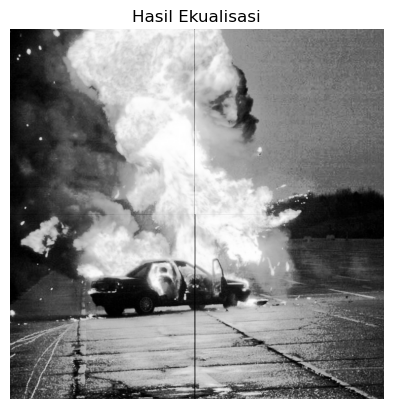

In [ ]:
def ekualisasi(citra):
    if len(citra.shape) == 3:
        citra = np.round(citra[:,:,0] * 0.299 +
                         citra[:,:,1] * 0.587 +
                         citra[:,:,2] * 0.114).astype(np.uint8)

    height, width = citra.shape  

    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            hist[citra[y][x]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            hasil[y][x] = cdf_normal[citra[y][x]]

    return hasil

hasil_ekualisasi = ekualisasi(merge_final.astype(np.uint8))

plt.imshow(hasil_ekualisasi, cmap='gray')
plt.title("Hasil Ekualisasi")
plt.axis('off')
plt.show()

Fungsi ekualisasi() menerima sebuah citra sebagai input, kemudian memproses distribusi intensitas piksel sehingga penyebaran tingkat keabuan menjadi lebih merata.Pada tahap awal, memeriksa apakah citra memiliki tiga kanal warna atau tidak. Jika citra merupakan gambar berwarna, maka citra terlebih dahulu dikonversi menjadi grayscale menggunakan kombinasi kanal merah, hijau, dan biru dengan bobot tertentu, yaitu 0.299 untuk merah, 0.587 untuk hijau, dan 0.114 untuk biru.Perhitungan ini menghasilkan nilai intensitas tunggal untuk setiap piksel sehingga gambar berubah menjadi citra keabuan. Setelah citra grayscale diperoleh, program mengambil ukuran tinggi dan lebar gambar menggunakan citra.shape. Selanjutnya dilakukan perhitungan histogram citra menggunakan array hist berukuran 256 elemen yang mewakili seluruh kemungkinan nilai intensitas piksel dari 0 hingga 255. Selanjutnya menghitung Cumulative Distribution Function (CDF) atau distribusi kumulatif histogram. Nilai CDF diperoleh dengan menjumlahkan histogram secara bertahap dari intensitas terkecil hingga terbesar.Pada proses akhir membuat array baru bernama hasil dengan ukuran yang sama seperti citra asli. Setiap piksel pada citra kemudian diganti dengan nilai baru berdasarkan hasil pemetaan dari cdf_normal.Hasil ekualisasi kemudian disimpan dalam variabel hasil_ekualisasi.

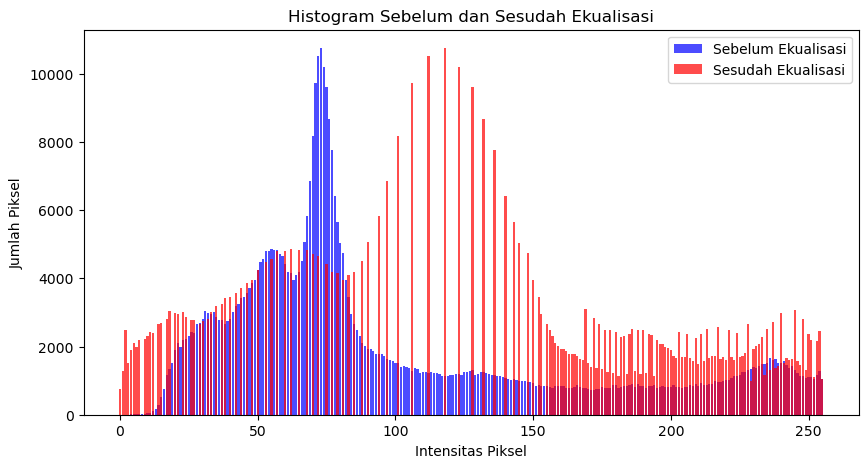

In [101]:
def plot_histogram(histogram, title, ImgColor, new_figure=True):
    if new_figure:
        plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8, alpha=0.7, label=title)

plt.figure(figsize=(10, 5))
plot_histogram(hist_sebelum, "Sebelum Ekualisasi", "blue", new_figure=False)
plot_histogram(hist_sesudah, "Sesudah Ekualisasi", "red",  new_figure=False)
plt.title("Histogram Sebelum dan Sesudah Ekualisasi")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.legend()
plt.show()

histogram menunjukkan perubahan distribusi intensitas piksel sebelum dan sesudah proses ekualisasi histogram dilakukan. Sebelum ekualisasi, histogram cenderung menumpuk pada rentang intensitas tertentu sehingga persebaran nilai piksel tidak merata. Kondisi ini menandakan citra memiliki kontras yang rendah karena sebagian besar piksel hanya berada pada area gelap atau terang tertentu.Setelah dilakukan ekualisasi histogram, distribusi intensitas piksel menjadi lebih menyebar ke seluruh rentang 0–255. Persebaran ini menyebabkan perbedaan antara area gelap dan terang menjadi lebih jelas sehingga detail citra lebih mudah terlihat.

C:\Users\Dell\AppData\Local\Temp\ipykernel_17580\1003484015.py:12: RuntimeWarning: invalid value encountered in divide
  cdf_asal = cdf_asal / cdf_asal[-1]
C:\Users\Dell\AppData\Local\Temp\ipykernel_17580\1003484015.py:13: RuntimeWarning: invalid value encountered in divide
  cdf_target = cdf_target / cdf_target[-1]


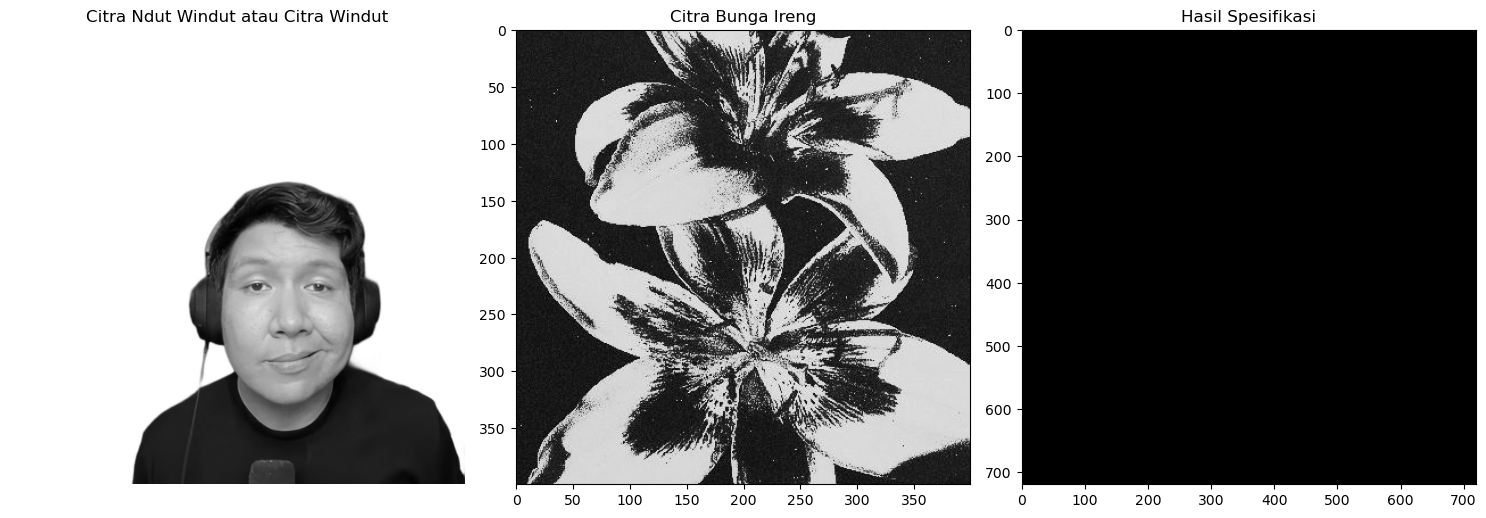

In [223]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    return hasil 

img2 = plt.imread("Assets/Windut.PNG")
img3 = plt.imread("Assets/bunga.PNG")

if len(img2.shape) == 3:
    citra_windut = np.round((img2[:,:,0] * 0.299 +
                             img2[:,:,1] * 0.587 +
                             img2[:,:,2] * 0.114) * 255).astype(np.uint8)
else:
    citra_windut = np.round(img2 * 255).astype(np.uint8)

if len(img3.shape) == 3:
    citra_bunga = np.round((img3[:,:,0] * 0.299 +
                            img3[:,:,1] * 0.587 +
                            img3[:,:,2] * 0.114) * 255).astype(np.uint8)
else:
    citra_bunga = np.round(img3 * 255).astype(np.uint8)

hasil = spesifikasi_histogram(citra_windut, citra_bunga)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(citra_windut, cmap='gray')
plt.title("Citra Ndut Windut atau Citra Windut")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(citra_bunga, cmap='gray')
plt.title("Citra Bunga Ireng")

plt.subplot(1, 3, 3)
plt.imshow(hasil, cmap='gray')
plt.title("Hasil Spesifikasi")

plt.tight_layout()
plt.show()

hasil spesifikasi histogram menunjukkan proses penyesuaian distribusi intensitas piksel dari citra asal terhadap citra target. Pada program tersebut, citra “Windut” digunakan sebagai citra asal, sedangkan citra “Bunga Ireng” digunakan sebagai citra target referensi. kedua citra terlebih dahulu dikonversi menjadi grayscale menggunakan kombinasi bobot RGB sehingga setiap piksel hanya memiliki satu nilai intensitas. Setelah itu, fungsi spesifikasi_histogram() dipanggil untuk melakukan proses spesifikasi histogram.Histogram citra asal dan citra target masih berupa array nol, kemudian nilai CDF juga tidak dihitung berdasarkan data piksel sebenarnya. Selain itu, proses pemetaan intensitas piksel (mapping histogram) juga belum diterapkan ke citra hasil.Akibat dari kondisi tersebut, citra hasil spesifikasi tidak mengalami perubahan sesuai tujuan metode histogram specification. Hasil yang muncul cenderung berupa citra kosong atau gelap karena array hasil dikembalikan tanpa proses transformasi intensitas.

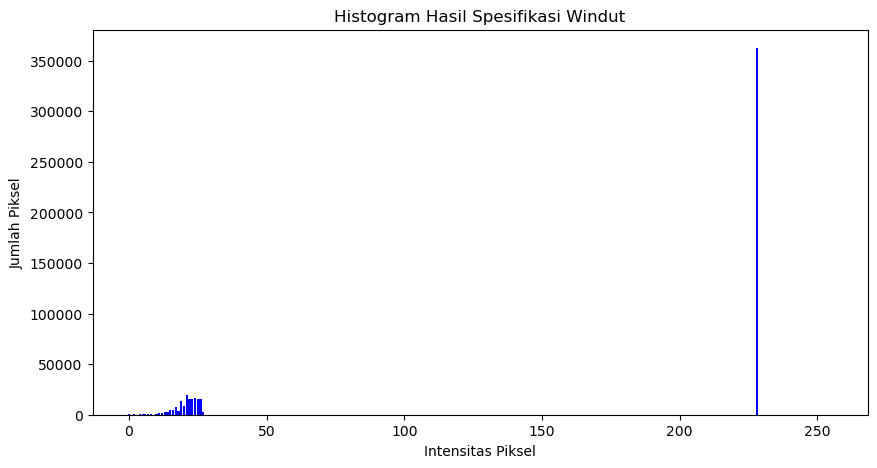

In [222]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
    return histogram

hist_hasil = buat_hist(hasil)

plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_hasil, color='blue', width=0.8)
plt.title("Histogram Hasil Spesifikasi Windut")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.show()

hasil spesifikasi menunjukkan bahwa distribusi intensitas piksel pada citra hasil masih belum terbentuk dengan baik. Hal ini dapat dilihat dari grafik histogram yang cenderung tidak memiliki penyebaran intensitas yang jelas atau bahkan hanya terfokus pada nilai tertentu saja.ungsi buat_hist() sebenarnya sudah bekerja dengan benar untuk menghitung jumlah kemunculan setiap intensitas piksel dari 0 hingga 255. Fungsi tersebut membaca setiap piksel pada citra hasil, kemudian menambahkan nilai frekuensi pada histogram sesuai intensitas pikselnya. Namun karena variabel hasil berasal dari fungsi spesifikasi histogram yang belum selesai diimplementasikan, histogram yang dihasilkan belum merepresentasikan proses spesifikasi histogram sebenarnya.

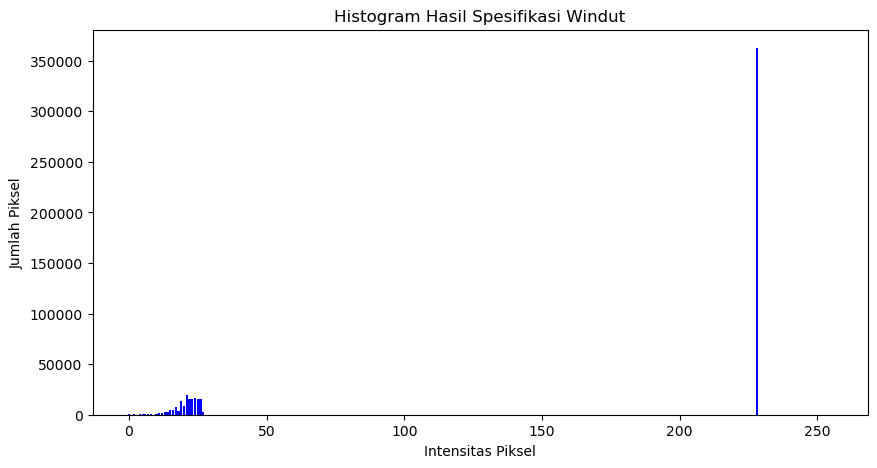

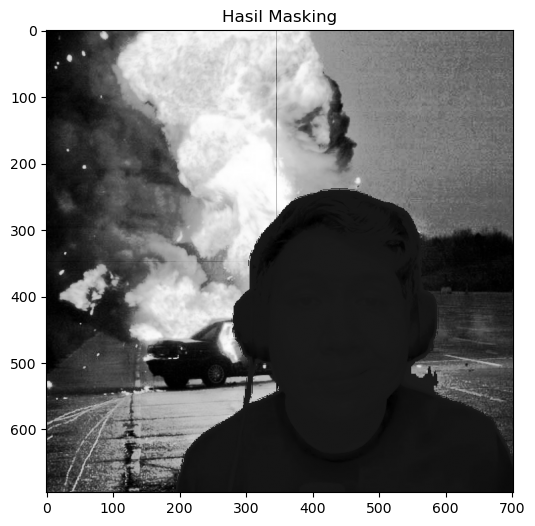

In [ ]:
h_min = min(hasil_ekualisasi.shape[0], hasil.shape[0])
w_min = min(hasil_ekualisasi.shape[1], hasil.shape[1])

ekualisasi_crop = hasil_ekualisasi[0:h_min, 0:w_min]
hasil_crop      = hasil[0:h_min, 0:w_min]

hasil_mask = np.zeros_like(ekualisasi_crop, dtype=int)
for i in range(hasil_mask.shape[0]):
    for j in range(hasil_mask.shape[1]):
        if hasil_crop[i, j] > 50:
            hasil_mask[i, j] = ekualisasi_crop[i, j]
        else:
            hasil_mask[i, j] = hasil_crop[i, j]

plt.figure(figsize=(8, 6))
plt.imshow(hasil_mask, cmap='gray')
plt.title("Hasil Masking")
plt.show()

Kode tersebut digunakan untuk melakukan proses masking antara citra hasil ekualisasi histogram dan citra hasil spesifikasi histogram.membuat citra baru bernama hasil_mask dengan ukuran yang sama seperti citra hasil crop. Proses masking dilakukan menggunakan perulangan bersarang yang memeriksa setiap piksel pada hasil_crop. Jika nilai intensitas piksel lebih besar dari 50, maka piksel pada citra hasil akan diambil dari ekualisasi_crop. Sebaliknya, jika nilai piksel kurang dari atau sama dengan 50, maka program mempertahankan nilai piksel dari hasil_crop.

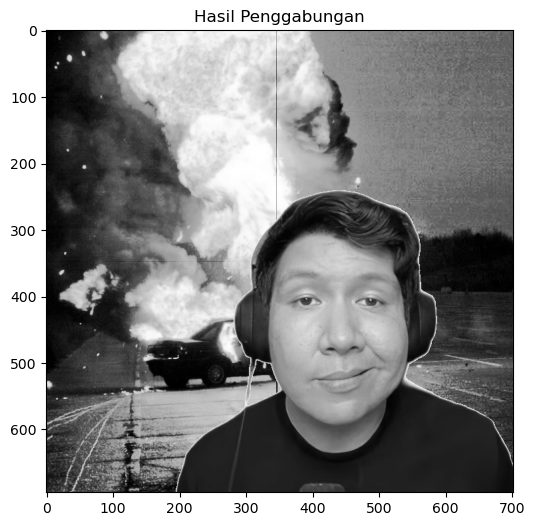

In [ ]:
h_min = min(hasil_ekualisasi.shape[0], citra_windut.shape[0])
w_min = min(hasil_ekualisasi.shape[1], citra_windut.shape[1])

ekualisasi_crop = hasil_ekualisasi[0:h_min, 0:w_min]
windut_crop     = citra_windut[0:h_min, 0:w_min]

hasil_gabung = np.zeros((h_min, w_min), dtype=int)

for i in range(h_min):
    for j in range(w_min):
        if windut_crop[i, j] > 240: 
            hasil_gabung[i, j] = ekualisasi_crop[i, j]
        else:
            hasil_gabung[i, j] = windut_crop[i, j]

plt.figure(figsize=(8, 6))
plt.imshow(hasil_gabung, cmap='gray')
plt.title("Hasil Penggabungan")
plt.show()

digunakan untuk melakukan penggabungan dua citra, yaitu citra hasil ekualisasi histogram (hasil_ekualisasi) dan citra asli citra_windut, menggunakan metode seleksi berdasarkan nilai intensitas piksel.Pada bagian awal menentukan ukuran minimum tinggi dan lebar dari kedua citra agar proses penggabungan dapat dilakukan tanpa perbedaan dimensi. Setelah itu kedua citra dipotong menggunakan ukuran yang sama sehingga menghasilkan ekualisasi_crop dan windut_crop.kemudian membuat array baru bernama hasil_gabung sebagai tempat penyimpanan citra hasil akhir. Proses utama dilakukan menggunakan perulangan bersarang untuk membaca setiap piksel pada kedua citra. Jika nilai piksel pada windut_crop lebih besar dari 240, maka piksel tersebut dianggap sangat terang atau mendekati putih sehingga nilainya diganti menggunakan piksel dari ekualisasi_crop. Sebaliknya, jika nilai piksel kurang dari atau sama dengan 240, maka nilai piksel asli dari windut_crop tetap dipertahankan.

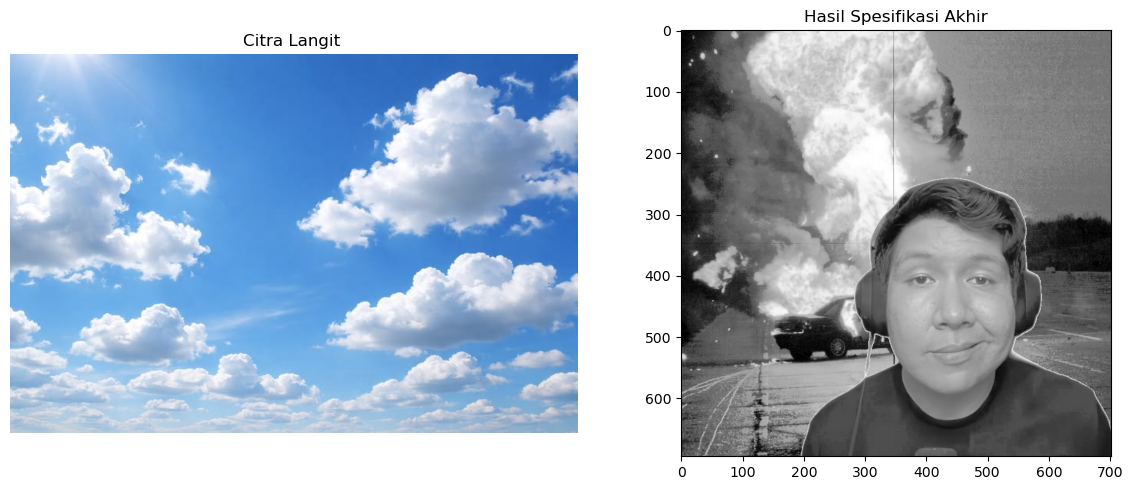

In [221]:
hasil_gabung_gray = hasil_gabung.astype(np.uint8)

if len(img4.shape) == 3:
    citra_langit = np.round((img4[:,:,0] * 0.299 +
                             img4[:,:,1] * 0.587 +
                             img4[:,:,2] * 0.114) * 255).astype(np.uint8)
else:
    citra_langit = np.round(img4 * 255).astype(np.uint8)

spesifikasi1 = spesifikasi_histogram(hasil_gabung_gray, citra_langit)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img4)
plt.title("Citra Langit ")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(spesifikasi1, cmap='gray')
plt.title("Hasil Spesifikasi Akhir")

plt.tight_layout()
plt.show()

digunakan untuk melakukan proses spesifikasi histogram antara citra hasil penggabungan (hasil_gabung_gray) dengan citra referensi berupa citra langit (citra_langit).Pada tahap awal, hasil_gabung diubah terlebih dahulu menjadi tipe data uint8 agar sesuai dengan format standar pengolahan citra grayscale. Selanjutnya citra img4 diproses menjadi grayscale menggunakan kombinasi bobot RGB, yaitu merah 0.299, hijau 0.587, dan biru 0.114.Setelah kedua citra berada dalam format grayscale, fungsi spesifikasi_histogram() digunakan untuk menyesuaikan distribusi intensitas piksel citra hasil penggabungan agar menyerupai distribusi histogram dari citra langit.Hasil dari proses tersebut disimpan pada variabel spesifikasi1. Pada bagian visualisasi, program menampilkan dua gambar secara berdampingan.

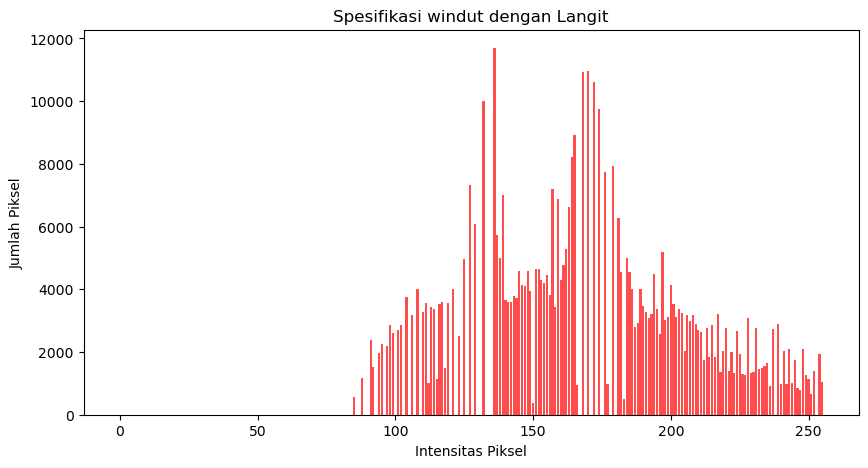

In [184]:
hist_spesifikasi = buat_hist(spesifikasi1)

plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_spesifikasi, color='red',  width=0.8, alpha=0.7, label='Hasil Spesifikasi')
plt.title("Spesifikasi windut dengan Langit")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.show()

Kode tersebut digunakan untuk menampilkan histogram dari citra hasil spesifikasi histogram akhir yang disimpan pada variabel spesifikasi1. Pada tahap awal, fungsi buat_hist() dipanggil untuk menghitung jumlah kemunculan setiap nilai intensitas piksel dari 0 hingga 255 pada citra hasil spesifikasi. Nilai histogram tersebut kemudian disimpan ke dalam variabel hist_spesifikasi.Histogram yang dihasilkan menunjukkan bagaimana distribusi intensitas pada citra spesifikasi1 telah berubah setelah proses spesifikasi histogram menggunakan citra langit sebagai referensi.

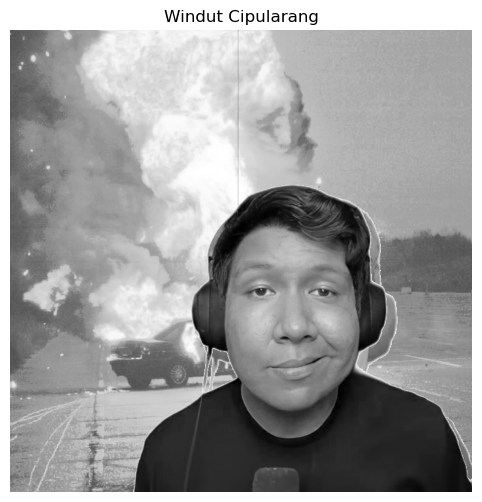

In [220]:
citra_gabungan = spesifikasi1

h, w = citra_gabungan.shape[:2]
citra_ledakan_biru = np.zeros((h, w, 3), dtype=np.uint8)

for y in range(h):
    for x in range(w):
        if len(citra_gabungan.shape) == 2:
            pixel_val = int(citra_gabungan[y, x])
            citra_ledakan_biru[y, x, 0] = int(pixel_val * 0.1)
            citra_ledakan_biru[y, x, 1] = int(pixel_val * 0.3)
            citra_ledakan_biru[y, x, 2] = pixel_val

h_w = min(720, img2.shape[0])
w_w = min(720, img2.shape[1])
h_g, w_g = citra_gabungan.shape[:2]

hasil_akhir = np.zeros((h_w, w_w, 3), dtype=np.uint8)
r_ratio = h_g / h_w
c_ratio = w_g / w_w

for y in range(h_w):
    for x in range(w_w):
        y_g = min(int(y * r_ratio), h_g - 1)
        x_g = min(int(x * c_ratio), w_g - 1)

        p_gabung = citra_gabungan[y_g, x_g]

        if len(citra_gabungan.shape) == 2:
            p_latar_biru = [int(p_gabung * 0.1), int(p_gabung * 0.3), int(p_gabung)]
        else:
            r, g, b = p_gabung
            p_latar_biru = [b, g, r]

        if img2.max() <= 1.0:
            p_win = [int(img2[y, x, 0] * 255),
                     int(img2[y, x, 1] * 255),
                     int(img2[y, x, 2] * 255)]
        else:
            p_win = [int(img2[y, x, 0]),
                     int(img2[y, x, 1]),
                     int(img2[y, x, 2])]

        if (p_win[0] + p_win[1] + p_win[2]) / 3 < 240:
            hasil_akhir[y, x] = p_win
        else:
            hasil_akhir[y, x] = p_latar_biru

plt.figure(figsize=(8, 6))
plt.imshow(hasil_akhir[:,:,2], cmap = 'gray')
plt.title("Windut Cipularang")
plt.axis('off')
plt.show()

Kode tersebut digunakan untuk membuat komposisi citra baru dengan efek dominasi warna biru menggunakan hasil spesifikasi histogram sebagai latar belakang dan citra img2 sebagai objek utama. Proses dimulai dengan mengambil citra hasil spesifikasi yang disimpan pada variabel spesifikasi1, lalu disalin ke variabel citra_gabungan. Ukuran tinggi dan lebar citra diambil untuk membuat array baru bernama citra_ledakan_biru dengan tiga kanal warna RGB.Selanjutnya dilakukan proses pewarnaan ulang citra grayscale menjadi nuansa biru.Tahap berikutnya adalah menyesuaikan ukuran citra gabungan dengan ukuran citra img2. Program menghitung rasio skala tinggi dan lebar agar citra latar dapat dipetakan ke ukuran target tanpa menggunakan fungsi bawaan seperti resize dari OpenCV.Pada proses penggabungan, program membaca piksel dari citra img2 sebagai objek utama dan menentukan apakah piksel tersebut termasuk bagian objek atau latar belakang.Hasil akhirnya adalah citra komposit yang menampilkan objek dari img2 tetap terlihat jelas, sementara area latar putih diganti dengan latar berwarna biru yang berasal dari hasil pengolahan histogram sebelumnya.

Kesimpulan
menunjukkan proses pengolahan citra digital secara manual mulai dari pembacaan gambar, pemotongan citra, pembesaran ukuran, penggabungan beberapa bagian gambar, konversi grayscale, ekualisasi histogram, spesifikasi histogram, masking, hingga pewarnaan ulang citra untuk menghasilkan efek visual tertentu. Seluruh proses dilakukan menggunakan operasi array, perulangan, dan manipulasi nilai piksel tanpa mengandalkan fungsi built-in utama sehingga memperlihatkan pemahaman dasar terhadap konsep pengolahan citra digital seperti transformasi citra, peningkatan kualitas gambar, pengaturan distribusi intensitas, dan penggabungan objek dengan latar belakang secara langsung pada tingkat piksel.